<a href="https://colab.research.google.com/github/sagara-pathum/Skit-learn/blob/main/8_Polynominal_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import sklearn
import numpy as np
import pandas as pd

In [4]:
np.random.seed(42) # for reproducibility


# To generate a data as distribution we need to specify the mean and covarience.
# since our data have two features we need to specify two dimentional mean and covarience
# look this video to understand the covarience https://www.youtube.com/watch?v=ekZQthaCrfU
# Class A: 100 samples near mean (0,0)
mean_a = [0, 0]
cov_a = [[1, 0],
         [0, 1]] #  This is the identity covariance matrix for spherical distribution
data_a = np.random.multivariate_normal(mean_a, cov_a, 100)
labels_a = ['a'] * 100

# Class B: 58 samples near mean (-10,8)
mean_b1 = [-10, 8]
cov_b1 = [[1, 0],
          [0, 1]]
data_b1 = np.random.multivariate_normal(mean_b1, cov_b1, 58)

# Class B: 42 samples near mean (-8,-6)
mean_b2 = [8, -6]
cov_b2 = [[1, 0],
          [0, 1]]
data_b2 = np.random.multivariate_normal(mean_b2, cov_b2, 42)

# since we generated the data for class B in two sepearate varibles.
# we need to combine them using 'stack- it has vstack and hstack'
# https://www.geeksforgeeks.org/python/numpy-vstack-in-python/
data_b = np.vstack((data_b1, data_b2))
labels_b = ['b'] * (58 + 42)

# Combine all data and labels
all_data = np.vstack((data_a, data_b))
all_labels = labels_a + labels_b

# Create a DataFrame
# here in pandas we can use 'DataFrame()' to make a dataframe. for that function we need to enter a numpy 'ndarray'. then we need to
# specify the columns names
# also we can add a colum to a exiting dataframe using a 'list'.
# for that we need to specify the colunm name as it is already in the dataframe and assign the list.
df = pd.DataFrame(all_data, columns=['x', 'y'])
df['class'] = all_labels

display(df.head())

,x,y,class
0,0.496714,-0.138264,a
1,0.647689,1.523030,a
2,-0.234153,-0.234137,a
3,1.579213,0.767435,a
4,-0.469474,0.542560,a


In [8]:
type(all_labels)
type(all_data)

numpy.ndarray

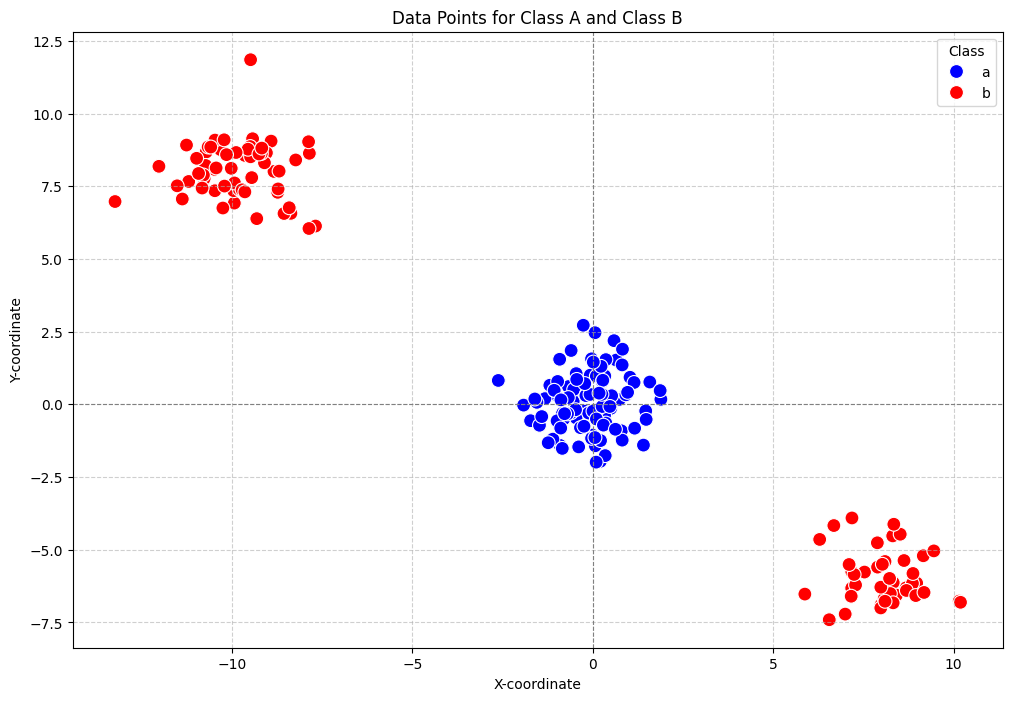

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# read this for pallete and seaborn scatter
# https://www.geeksforgeeks.org/data-visualization/how-to-specify-multiple-variables-for-the-hue-parameters-in-seaborn/
sns.scatterplot(data=df, x='x', y='y', hue='class', palette={'a': 'blue', 'b': 'red'}, s=100)
plt.title('Data Points for Class A and Class B')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(title='Class')
plt.show()

In [11]:
df['x_squared'] = df['x']**2
df['y_squared'] = df['y']**2
df['xy'] = df['x'] * df['y']

# Create a new DataFrame with all five parameters and the class column
df_features = df[['x', 'y', 'x_squared', 'y_squared', 'xy', 'class']].copy()

display(df_features.head())

,x,y,x_squared,y_squared,xy,class
0,0.496714,-0.138264,0.246725,0.019117,-0.068678,a
1,0.647689,1.523030,0.419500,2.319620,0.986449,a
2,-0.234153,-0.234137,0.054828,0.054820,0.054824,a
3,1.579213,0.767435,2.493913,0.588956,1.211943,a
4,-0.469474,0.542560,0.220406,0.294371,-0.254718,a


In [ ]:
# GENERATED CODES FOR 3D-visualization.
# READ THE CODE LATER

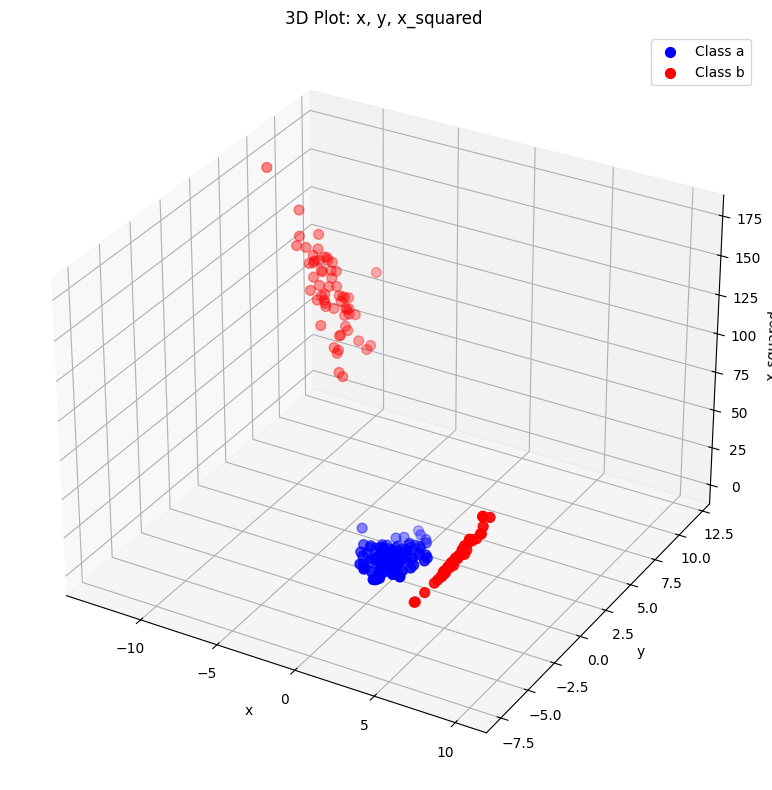

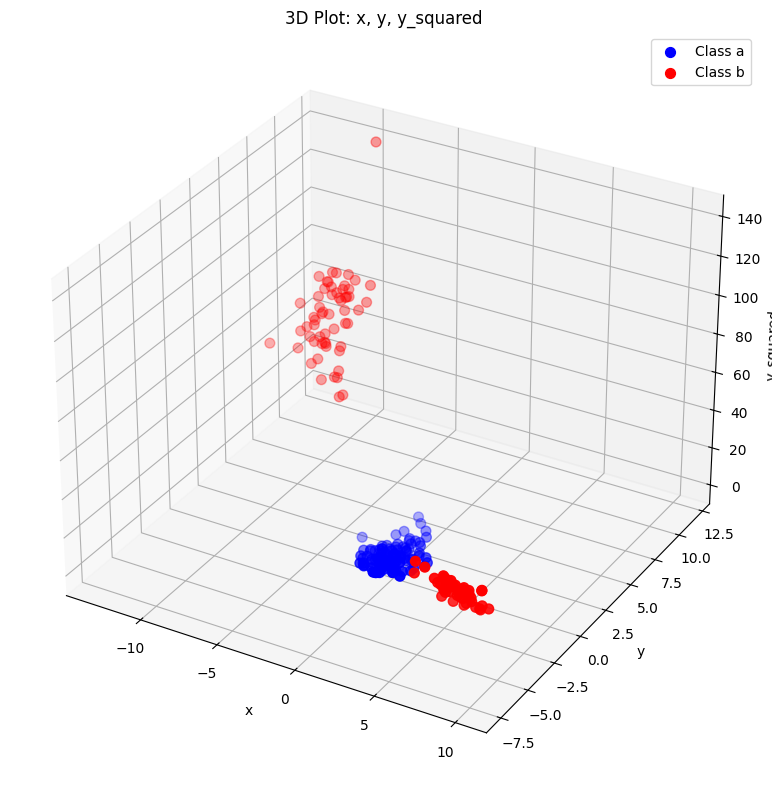

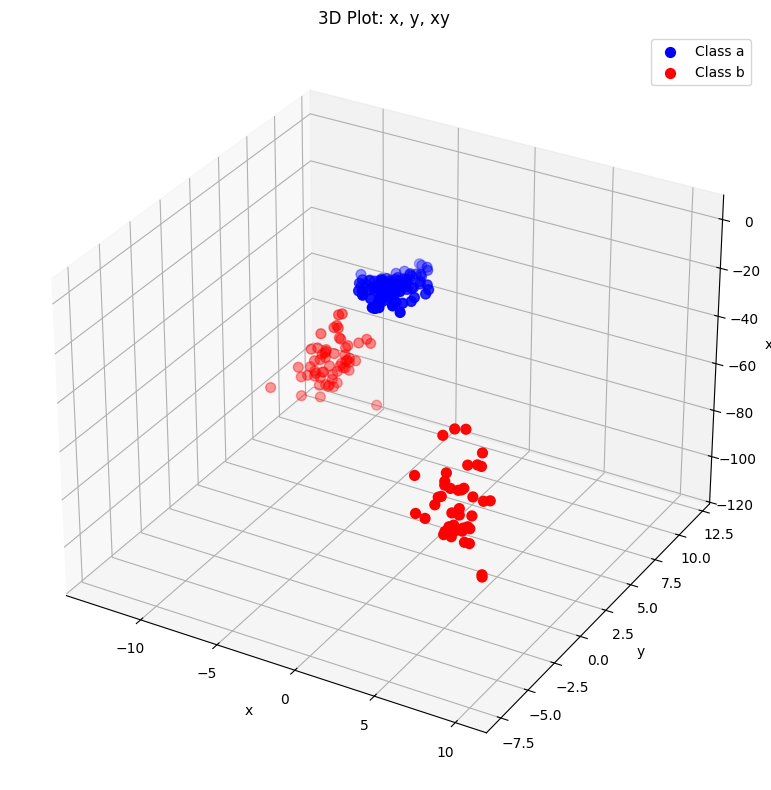

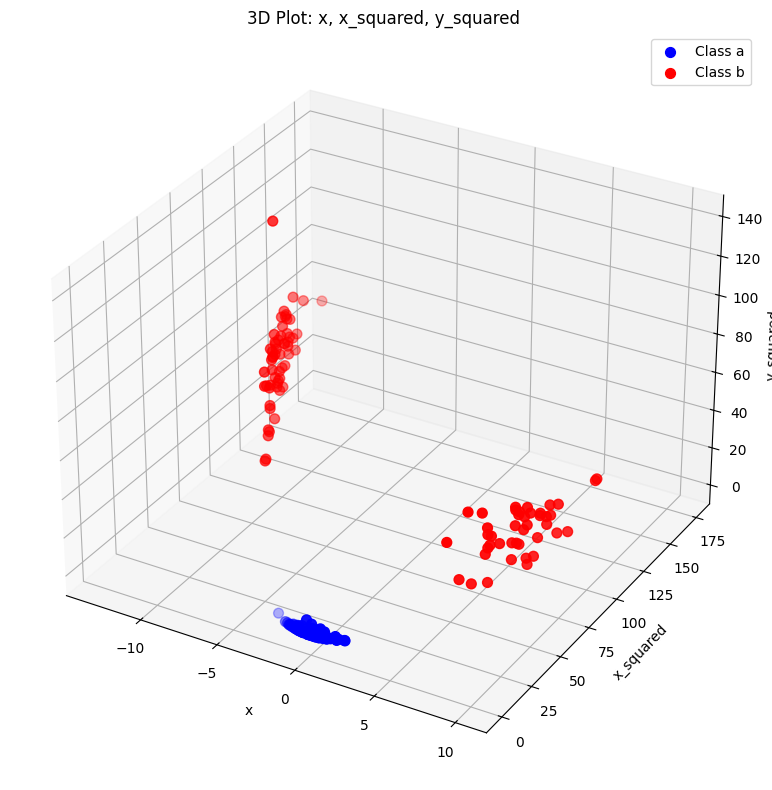

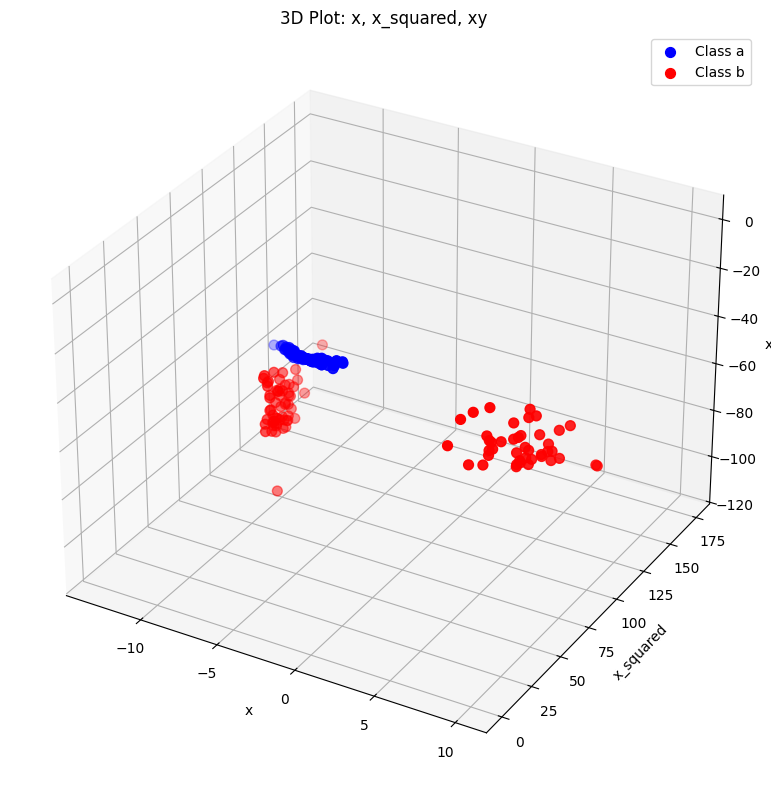

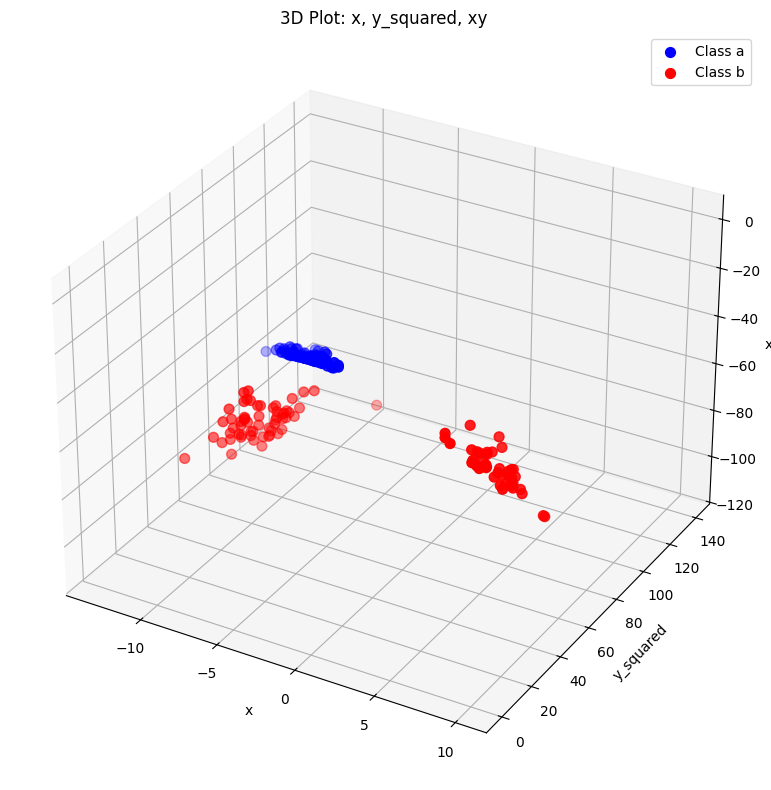

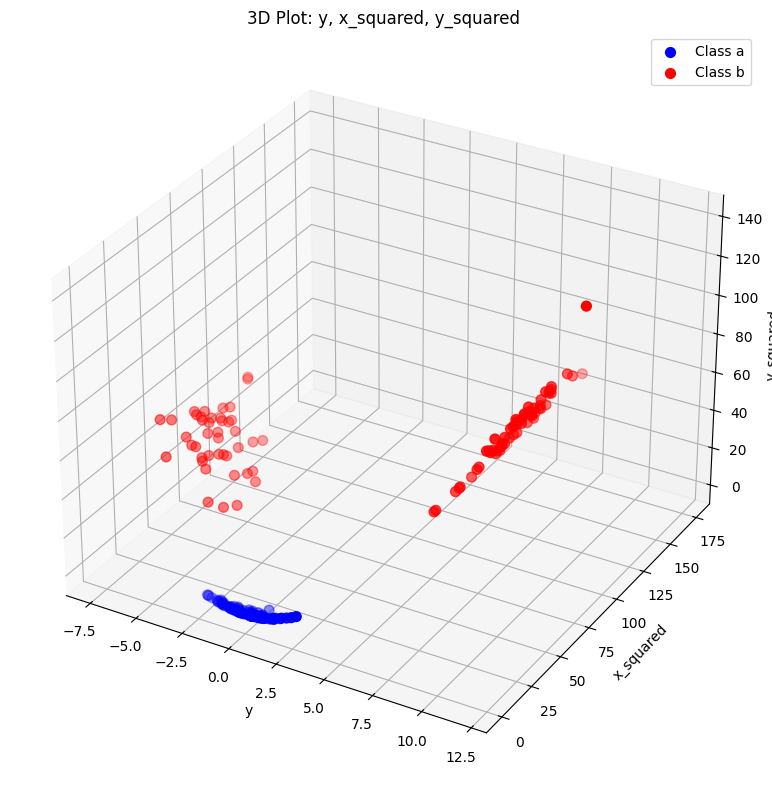

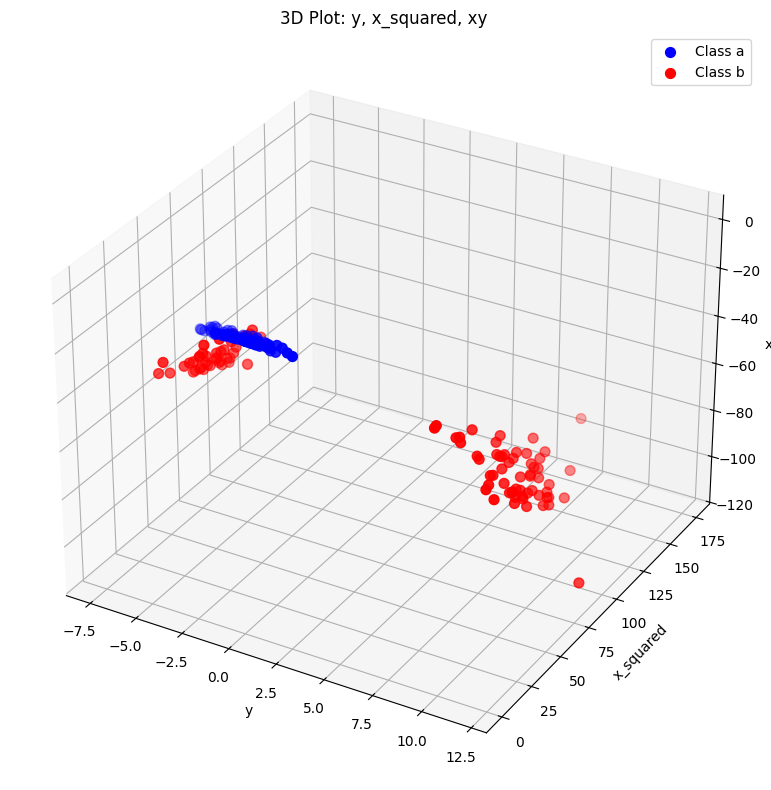

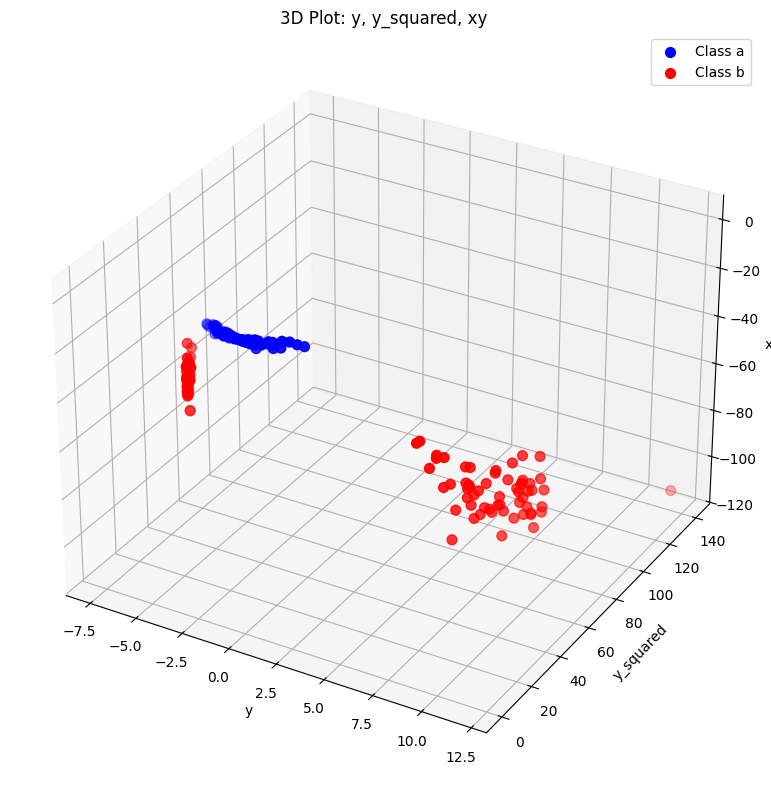

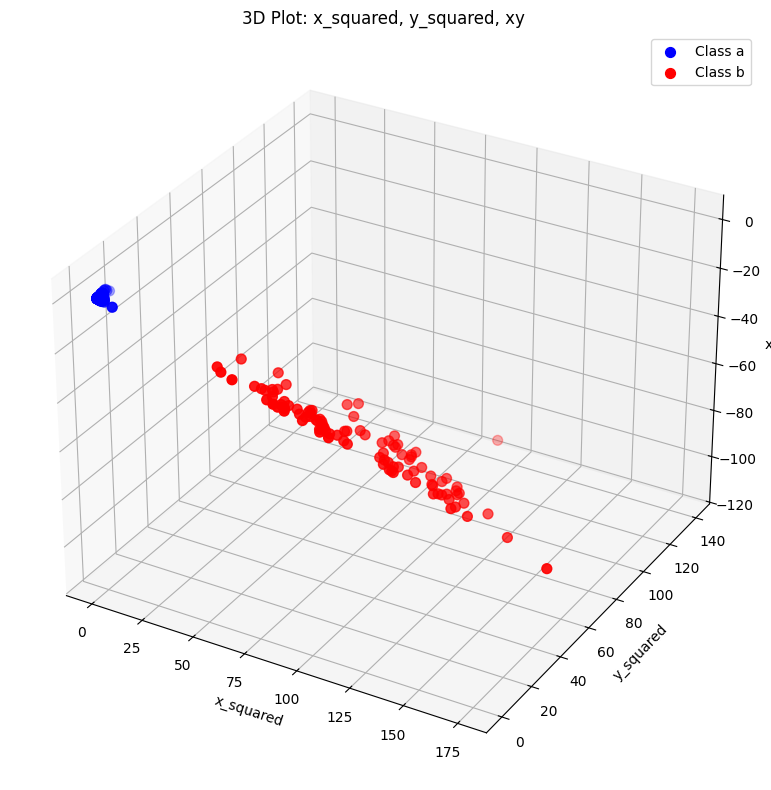

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import itertools

# Define the features to use for plotting
features = ['x', 'y', 'x_squared', 'y_squared', 'xy']

# Get unique classes and define colors
unq_classes = df_features['class'].unique()
colors = {'a': 'blue', 'b': 'red'}

# Generate all combinations of 3 features
feature_combinations = list(itertools.combinations(features, 3))

# Create 3D plots for each combination
for i, combo in enumerate(feature_combinations):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot data for each class
    for c in unq_classes:
        class_df = df_features[df_features['class'] == c]
        ax.scatter(class_df[combo[0]], class_df[combo[1]], class_df[combo[2]],
                   color=colors[c], label=f'Class {c}', s=50)

    ax.set_xlabel(combo[0])
    ax.set_ylabel(combo[1])
    ax.set_zlabel(combo[2])
    ax.set_title(f'3D Plot: {combo[0]}, {combo[1]}, {combo[2]}')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [13]:
import plotly.express as px

# Select one combination for demonstration
combo = ('x', 'y', 'x_squared')

# Create an interactive 3D scatter plot using Plotly Express
fig = px.scatter_3d(df_features,
                    x=combo[0],
                    y=combo[1],
                    z=combo[2],
                    color='class', # Color points by the 'class' column
                    color_discrete_map={'a': 'blue', 'b': 'red'},
                    title=f'Interactive 3D Plot: {combo[0]}, {combo[1]}, {combo[2]}')

fig.show()

In [ ]:
# as you can see. even if it is seem to inseperable the cluster in two dimentions.
# if we project data into 3 dimentions using feature relations it can be separable.
# futher , the new axis can be named like arbirary axis. ex (x squared = z)
# then the whole plot becomes leniar in calculations. ex(z = x + 3y)
# it is a linear equation. so it is a flat surface. not curved. it can separate data.

In [ ]:
# so when we have such data for our task. what we do is we project them in to higher dimentions.
# then use ml to predict the most usitaple plaine or whatever linear thing that can seperate the data.
# then we take that equation back into our 2d minesions if we want. then it may be a not a linear in that dimentions.

# ex (z = -3x +y +5)  --> (y = x^2 +3x -5)

# you will see the machine leaning aproch in next script